# LDA on Imbalanced Dataset — Step by Step

**Dataset:** `lda_imbalanced.csv`  
**Objective:** Understand how **class imbalance** affects Linear Discriminant Analysis (LDA).

We will:
1. Load and inspect the dataset
2. Check class imbalance
3. Standardize features
4. Apply LDA
5. Visualize the 1D LDA projection
6. Compute class means and scatter matrices
7. Answer the assignment questions

## Step 1 — Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report

## Step 2 — Load the Dataset

The dataset has feature columns and one target/label column. Here, the last column is assumed to be the class label.

In [2]:
# Load dataset
# Make sure lda_imbalanced.csv is in the same folder as this notebook.
data = pd.read_csv("lda_imbalanced.csv")

# Display first 5 rows
data.head()

,F1,F2,F3,F4,Label
0,-1.707003,0.019432,-1.989890,-1.789479,0
1,-1.426683,0.006319,-1.591441,-1.528047,0
2,-0.459894,-0.017192,-0.374102,-0.555422,0
3,-0.412570,-0.011176,-0.366283,-0.484387,0
4,0.500051,-0.264747,2.454234,-0.322561,1


## Step 3 — Basic Dataset Information

In [4]:
print("Dataset shape:", data.shape)

print(data.columns.tolist())


print(data.isnull().sum())

Dataset shape: (500, 5)
['F1', 'F2', 'F3', 'F4', 'Label']
F1       0
F2       0
F3       0
F4       0
Label    0
dtype: int64


## Step 4 — Separate Features and Target

`X` contains input features.  
`y` contains class labels.

In [6]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Target column name:", data.columns[-1])

Feature shape: (500, 4)
Target shape: (500,)
Target column name: Label


## Step 5 — Check Class Distribution

Class imbalance means one class has many more samples than another class.

Label
0    448
1     52
Name: count, dtype: int64


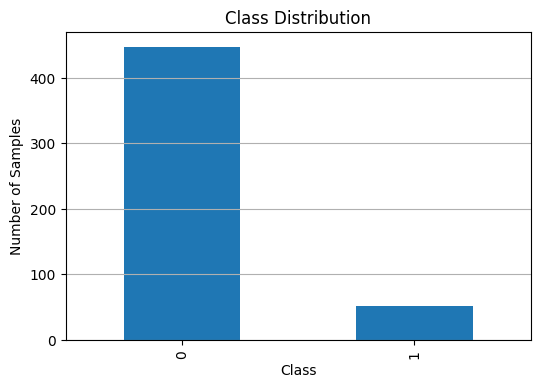

In [7]:
class_counts = y.value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.grid(axis="y")
plt.show()

### Observation

In this dataset, class `0` is the **majority class** and class `1` is the **minority class**.  
This imbalance can make the LDA projection more influenced by the majority class.

## Step 6 — Standardize Features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,F1,F2,F3,F4
0,-1.610771,-0.428233,-1.125328,-1.456453
1,-1.309440,-0.527835,-0.756684,-1.246190
2,-0.270188,-0.706412,0.369597,-0.463937
3,-0.219318,-0.660719,0.376831,-0.406806
4,0.761706,-2.586754,2.986370,-0.276654


## Step 7 — Apply LDA

For a two-class problem, LDA can project the data into **one dimension**.

In [11]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print("Original feature shape:", X_scaled.shape)
print("LDA transformed shape:", X_lda.shape)
print("First 10 projected values:")
print(X_lda[:10].ravel())

Original feature shape: (500, 4)
LDA transformed shape: (500, 1)
First 10 projected values:
[-0.85395956 -0.46927738  0.65100628  0.63771199  3.89488468  0.41273878
 -1.5068512   0.67236596 -0.34698746 -0.67677372]


## Step 8 — Visualize LDA Projection using Histogram

This shows how both classes are distributed after projection into 1D.

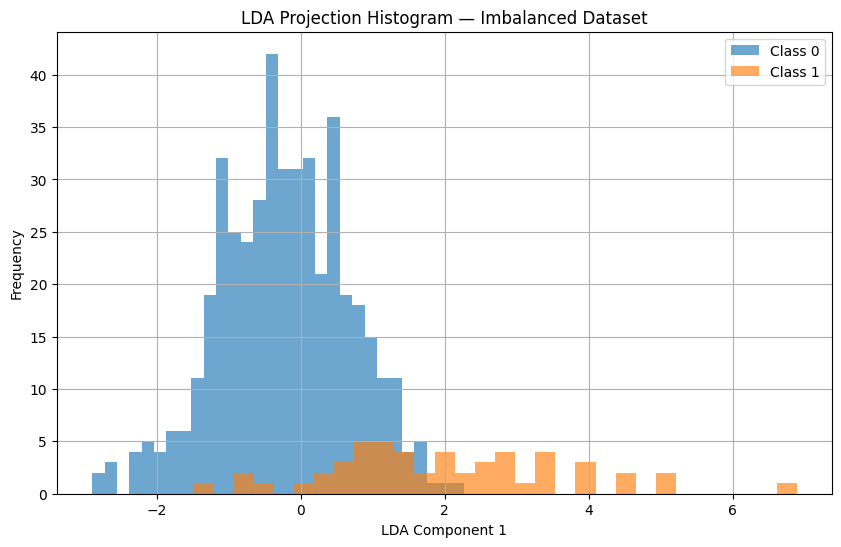

In [12]:
classes = sorted(y.unique())

plt.figure(figsize=(10,6))
for cls in classes:
    plt.hist(
        X_lda[y == cls].ravel(),
        bins=30,
        alpha=0.65,
        label=f"Class {cls}"
    )

plt.xlabel("LDA Component 1")
plt.ylabel("Frequency")
plt.title("LDA Projection Histogram — Imbalanced Dataset")
plt.legend()
plt.grid(True)
plt.show()

## Step 9 — Visualize LDA Projection using Scatter Plot

This plot places the two classes on different y-levels, so overlap is easier to see.

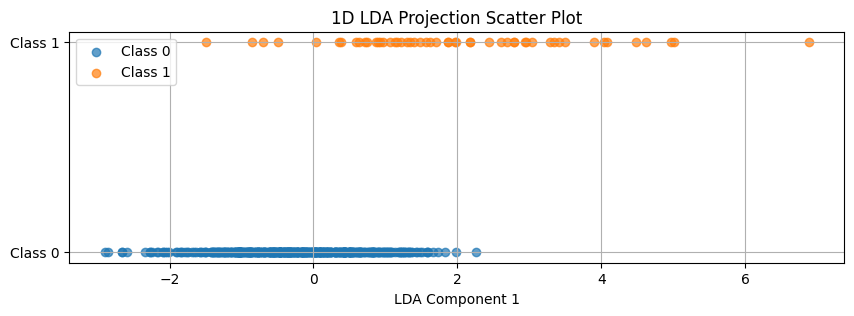

In [13]:
plt.figure(figsize=(10,3))

for i, cls in enumerate(classes):
    plt.scatter(
        X_lda[y == cls].ravel(),
        np.full(sum(y == cls), i),
        alpha=0.7,
        label=f"Class {cls}"
    )

plt.yticks(range(len(classes)), [f"Class {cls}" for cls in classes])
plt.xlabel("LDA Component 1")
plt.title("1D LDA Projection Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()

## Step 10 — Compare Class Means After LDA Projection

If means are far apart, class separation is better.  
If means are close, classes overlap more.

In [14]:
projection_summary = pd.DataFrame({
    "Class": classes,
    "Count": [sum(y == cls) for cls in classes],
    "Projected Mean": [X_lda[y == cls].mean() for cls in classes],
    "Projected Std Dev": [X_lda[y == cls].std() for cls in classes]
})

projection_summary

,Class,Count,Projected Mean,Projected Std Dev
0,0,448,-0.232990,0.894553
1,1,52,2.007295,1.637888


## Step 11 — Compute Class Means in Original Standardized Feature Space

In [15]:
class_means = {}

for cls in classes:
    class_means[cls] = X_scaled[y == cls].mean(axis=0)
    print(f"Class {cls} mean:")
    print(class_means[cls])
    print()

Class 0 mean:
[-0.05919265  0.14534253 -0.18308456  0.0022291 ]

Class 1 mean:
[ 0.50996745 -1.25218181  1.57734388 -0.01920453]



## Step 12 — Compute Within-Class Scatter Matrix $S_W$

Within-class scatter tells us how spread out each class is internally.

For each class:

$$
S_i = \sum (x - \mu_i)(x - \mu_i)^T
$$

Total within-class scatter:

$$
S_W = S_1 + S_2 + ... + S_k
$$

In [16]:
n_features = X_scaled.shape[1]
Sw = np.zeros((n_features, n_features))

for cls in classes:
    X_cls = X_scaled[y == cls]
    mean_cls = class_means[cls]
    centered = X_cls - mean_cls
    Sw += centered.T @ centered

print("Within-class scatter matrix Sw:")
print(Sw)

Within-class scatter matrix Sw:
[[ 484.9068376   233.22561994  246.98796339  474.5535446 ]
 [ 233.22561994  409.00236292 -142.38017065  330.9805764 ]
 [ 246.98796339 -142.38017065  355.60634771  151.32002588]
 [ 474.5535446   330.9805764   151.32002588  499.97859562]]


## Step 13 — Compute Between-Class Scatter Matrix $S_B$

Between-class scatter tells us how far class means are from the overall mean.

Formula:

$$
S_B = \sum N_i(\mu_i - \mu)(\mu_i - \mu)^T
$$

Where:
- $N_i$ = number of samples in class $i$
- $\mu_i$ = class mean
- $\mu$ = overall mean

In [17]:
overall_mean = X_scaled.mean(axis=0)
Sb = np.zeros((n_features, n_features))

for cls in classes:
    X_cls = X_scaled[y == cls]
    n_cls = X_cls.shape[0]
    mean_diff = (class_means[cls] - overall_mean).reshape(-1, 1)
    Sb += n_cls * (mean_diff @ mean_diff.T)

print("Between-class scatter matrix Sb:")
print(Sb)

Between-class scatter matrix Sb:
[[ 1.50931624e+01 -3.70599800e+01  4.66835822e+01 -5.68383448e-01]
 [-3.70599800e+01  9.09976371e+01 -1.14627576e+02  1.39561734e+00]
 [ 4.66835822e+01 -1.14627576e+02  1.44393652e+02 -1.75802623e+00]
 [-5.68383448e-01  1.39561734e+00 -1.75802623e+00  2.14043774e-02]]


## Step 14 — Manual LDA Projection Vector

LDA tries to maximize:

$$
J(w)=rac{w^T S_B w}{w^T S_W w}
$$

The projection direction can be found from eigenvectors of:

$$
S_W^{-1}S_B
$$

In [19]:
# Use pseudo-inverse for numerical stability
A = np.linalg.pinv(Sw) @ Sb

eigenvalues, eigenvectors = np.linalg.eig(A)

# Sort eigenvectors by eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues.real[sorted_indices]
eigenvectors = eigenvectors.real[:, sorted_indices]

print("Eigenvalues:")
print(eigenvalues)

print(" Top LDA direction vector:")
w = eigenvectors[:, 0]
print(w)

Eigenvalues:
[ 4.69557285e-01  4.63078825e-18  0.00000000e+00 -7.85645650e-20]
 Top LDA direction vector:
[ 0.2204528  -0.62060674  0.75164474 -0.03574952]


## Step 15 — Predict Classes using LDA and Check Performance

This helps us see whether imbalance affects minority-class prediction.

In [21]:
y_pred = lda.predict(X_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

print("Classification Report:")
print(classification_report(y, y_pred))

Confusion Matrix:
[[446   2]
 [ 26  26]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       448
           1       0.93      0.50      0.65        52

    accuracy                           0.94       500
   macro avg       0.94      0.75      0.81       500
weighted avg       0.94      0.94      0.94       500



# Assignment Questions and Answers

## Q1. Is one class dominating the projection?

Yes. The majority class dominates the projection because it has many more samples.  
In this dataset, class `0` has many more records than class `1`, so the estimated spread and decision boundary are influenced more by class `0`.

In the histogram, you will usually see class `0` having a much taller and wider distribution because it has more samples.

## Q2. How does imbalance affect class means?

Each class mean is calculated separately, so the minority class still has its own mean.

However, imbalance affects the **overall mean** and the **scatter matrices** because the majority class contributes more samples.

So the majority class pulls the overall distribution more strongly.

## Q3. Does LDA treat both classes equally?

Not fully.

LDA calculates separate class means, but the pooled covariance and scatter estimation are strongly affected by sample counts.  
So when one class has many more samples, LDA can become biased toward the majority class.

## Q4. What risks does imbalance introduce?

Class imbalance introduces these risks:

1. **Minority class may be ignored**
2. **Decision boundary may favor majority class**
3. **Recall for minority class may be low**
4. **Accuracy can be misleading**
5. **Fraud, disease, or rare-event cases may be missed**

Example: If 90% of data belongs to class `0`, a model can get high accuracy by mostly predicting class `0`, but it may fail badly on class `1`.

# Final Conclusion

LDA can work on imbalanced datasets, but class imbalance can bias the projection and classification result.

For imbalanced data, always check:

- Class distribution
- Confusion matrix
- Precision, recall, and F1-score
- Minority-class performance

Possible solutions:

- Oversampling minority class
- Undersampling majority class
- SMOTE
- Class-weighted models
- Trying other algorithms like Random Forest, XGBoost, or SVM with class weights